# PulseMetrics — Churn Prediction (Project 2)


Using the same PulseMetrics dataset, I built a churn prediction model in Python. I engineered customer features and trained a logistic regression model to identify customers at high risk of churning, allowing the business to take action before it's too late.

## 1. Load the data

Same 5 tables from PulseMetrics, pulled via pandas (mirrors the MySQL pull used locally).

In [1]:
import pandas as pd

customers = pd.read_csv('data/customers.csv')
subscriptions = pd.read_csv('data/subscriptions.csv')
support_tickets = pd.read_csv('data/support_tickets.csv')
monthly_usage = pd.read_csv('data/monthly_usage.csv')

print(customers.shape, subscriptions.shape, support_tickets.shape, monthly_usage.shape)

(1500, 6) (1500, 7) (4954, 7) (17317, 5)


In [2]:
customers.head()

,customer_id,company_name,industry,country,acquisition_channel,signup_date
0,1,"Rodriguez, Figueroa and Sanchez",EdTech,Germany,Cold Outreach,2023-04-13
1,2,Doyle Ltd,Real Estate,Netherlands,Organic Search,2025-06-18
2,3,"Mcclain, Miller and Henderson",E-commerce,Netherlands,Organic Search,2025-04-09
3,4,Davis and Sons,E-commerce,Germany,Organic Search,2023-01-02
4,5,"Guzman, Hoffman and Baldwin",Logistics,India,Referral,2023-03-13


In [3]:
subscriptions['status'].value_counts()

status
active       971
cancelled    529
Name: count, dtype: int64

## 2. Feature engineering

A model needs one row per customer with signals describing them — plan, channel, tenure, support activity, engagement. Raw tables are one-row-per-ticket or one-row-per-month, so they need to be aggregated to one row per customer *before* merging, or a merge will fan out into duplicate rows.

In [4]:
start = pd.to_datetime(subscriptions['start_date'])
end = pd.to_datetime(subscriptions['end_date'].fillna('2025-06-30'))
subscriptions['tenure_months'] = (
    (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)
    - (end.dt.day < start.dt.day).astype(int)
)

subscriptions['churned'] = (subscriptions['status'] == 'cancelled').astype(int)

ticket_summary = support_tickets.groupby('customer_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

usage_summary = monthly_usage.groupby('customer_id').agg(
    avg_monthly_active_days=('active_days', 'mean')
).reset_index()

df = (
    customers[['customer_id', 'acquisition_channel']]
    .merge(subscriptions[['customer_id', 'plan_id', 'tenure_months', 'churned']], on='customer_id', how='left')
    .merge(ticket_summary[['customer_id', 'total_tickets', 'avg_satisfaction']], on='customer_id', how='left')
    .merge(usage_summary[['customer_id', 'avg_monthly_active_days']], on='customer_id', how='left')
)

df.shape

(1500, 8)

### Null check

Nulls in `total_tickets`/`avg_satisfaction` mean the customer had **zero** support tickets — not missing data, a real zero. They need different fills: `total_tickets` → 0 (the true value), `avg_satisfaction` → dataset mean (filling with 0 would falsely say "extremely unhappy" for customers who simply never had a problem).

In [5]:
df.isna().sum()

customer_id                  0
acquisition_channel          0
plan_id                      0
tenure_months                0
churned                      0
total_tickets              110
avg_satisfaction           110
avg_monthly_active_days      0
dtype: int64

In [6]:
df['total_tickets'] = df['total_tickets'].fillna(0)
df['avg_satisfaction'] = df['avg_satisfaction'].fillna(df['avg_satisfaction'].mean())
df.isna().sum()

customer_id                0
acquisition_channel        0
plan_id                    0
tenure_months              0
churned                    0
total_tickets              0
avg_satisfaction           0
avg_monthly_active_days    0
dtype: int64

### Encoding categorical variables

`acquisition_channel` is **nominal** (no real order) → one-hot encode it. `plan_id` is **ordinal** (Starter < Growth < Scale < Enterprise represents real increasing value) → leave it as a number.

In [7]:
df = pd.get_dummies(df, columns=['acquisition_channel'], drop_first=True)
df.columns

Index(['customer_id', 'plan_id', 'tenure_months', 'churned', 'total_tickets',
       'avg_satisfaction', 'avg_monthly_active_days',
       'acquisition_channel_Content Marketing',
       'acquisition_channel_Organic Search', 'acquisition_channel_Paid Ads',
       'acquisition_channel_Partnership', 'acquisition_channel_Referral'],
      dtype='str')

## 3. Train/test split

Splitting *before* training, and holding the test set back entirely, is what lets us tell the difference between a model that learned real patterns and one that just memorized the training data (overfitting). `stratify=y` keeps the ~35/65 churn split consistent in both the train and test sets.

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['customer_id', 'churned'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((1200, 10), (300, 10))

## 4. Baseline model

Before judging any model, know the baseline: guessing "active" for every customer would already be right ~65% of the time, since that's the majority class. Any real model needs to clear that bar by a meaningful margin.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6433333333333333
Precision: 0.4918032786885246
Recall: 0.2830188679245283
F1: 0.3592814371257485
Confusion Matrix:
 [[163  31]
 [ 76  30]]


**Result:** this baseline actually performed *worse* than the do-nothing 65% floor, and recall was very low — the model defaulted to predicting "active" most of the time because it's optimizing for overall error, not specifically for catching the minority (churned) class.

## 5. Fixing it: class-weighted model

`class_weight='balanced'` penalizes mistakes on the minority class (churned) more heavily during training, forcing the model to actually pay attention to them instead of coasting on the majority class.

In [10]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6333333333333333
Precision: 0.4864864864864865
Recall: 0.6792452830188679
F1: 0.5669291338582677
Confusion Matrix:
 [[118  76]
 [ 34  72]]


**Why this trade-off is correct for churn specifically:** missing a real churner (false negative) costs the business the entire customer relationship. Flagging a customer who was actually going to stay (false positive) just costs an unnecessary retention email. The asymmetric cost means recall matters more than raw accuracy here — a trade-off that would be *wrong* for a different problem, like spam filtering, where false positives are the expensive mistake.

## 6. Which features actually drive churn?

Features need to be standardized (same scale) before comparing coefficients fairly — otherwise a naturally large-scale feature looks artificially less important than it really is.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LogisticRegression(max_iter=1000, class_weight='balanced')
model_scaled.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model_scaled.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coefficients

,feature,coefficient
1,tenure_months,-0.631236
0,plan_id,-0.414060
9,acquisition_channel_Referral,-0.200319
3,avg_satisfaction,-0.126429
8,acquisition_channel_Partnership,-0.117030
5,acquisition_channel_Content Marketing,-0.098225
6,acquisition_channel_Organic Search,-0.061191
4,avg_monthly_active_days,0.058653
7,acquisition_channel_Paid Ads,0.008446
2,total_tickets,0.005514


**Reading this:** `tenure_months` and `plan_id` are the strongest predictors — matches Project 1's SQL findings exactly (longer tenure and higher-tier plans both mean lower churn).

`total_tickets` sits near zero, which does *not* mean it's unimportant — it means its signal is already captured through `avg_satisfaction`, which the correlation check below confirms.

In [12]:
df[['total_tickets', 'avg_satisfaction']].corr()

,total_tickets,avg_satisfaction
total_tickets,1.000000,-0.359756
avg_satisfaction,-0.359756,1.000000


-0.36 — a real, moderate negative correlation. This is **multicollinearity**: two features carrying overlapping information, so the model concentrates its weight on one (`avg_satisfaction`) and discounts the other (`total_tickets`) rather than double-counting the same underlying signal. Both are really measuring the same root cause identified in Project 1 — whether a customer feels heard and gets their problem solved.

## 7. Visual EDA

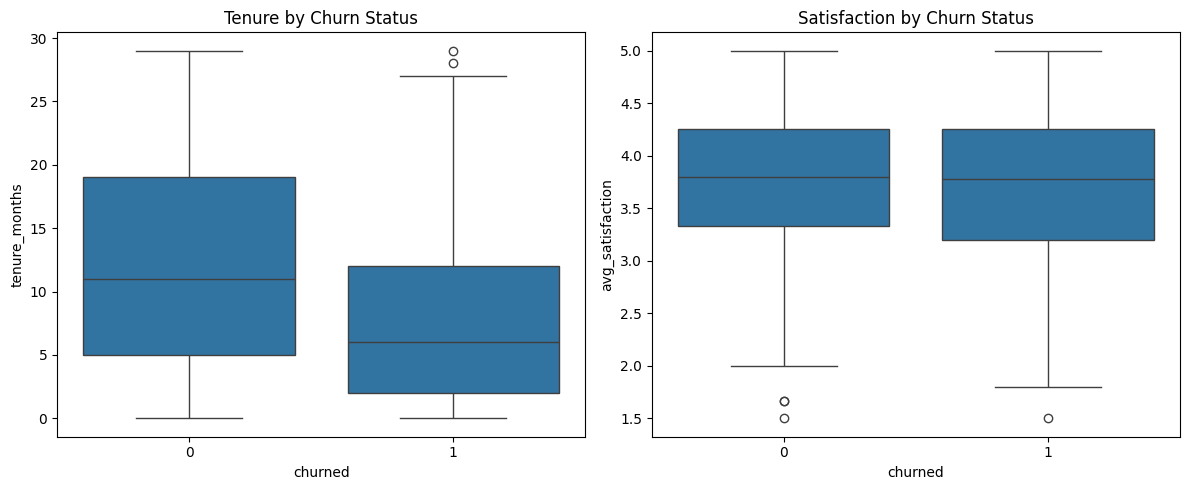

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='churned', y='tenure_months', ax=axes[0])
axes[0].set_title('Tenure by Churn Status')
sns.boxplot(data=df, x='churned', y='avg_satisfaction', ax=axes[1])
axes[1].set_title('Satisfaction by Churn Status')
plt.tight_layout()
plt.savefig('tenure_satisfaction_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

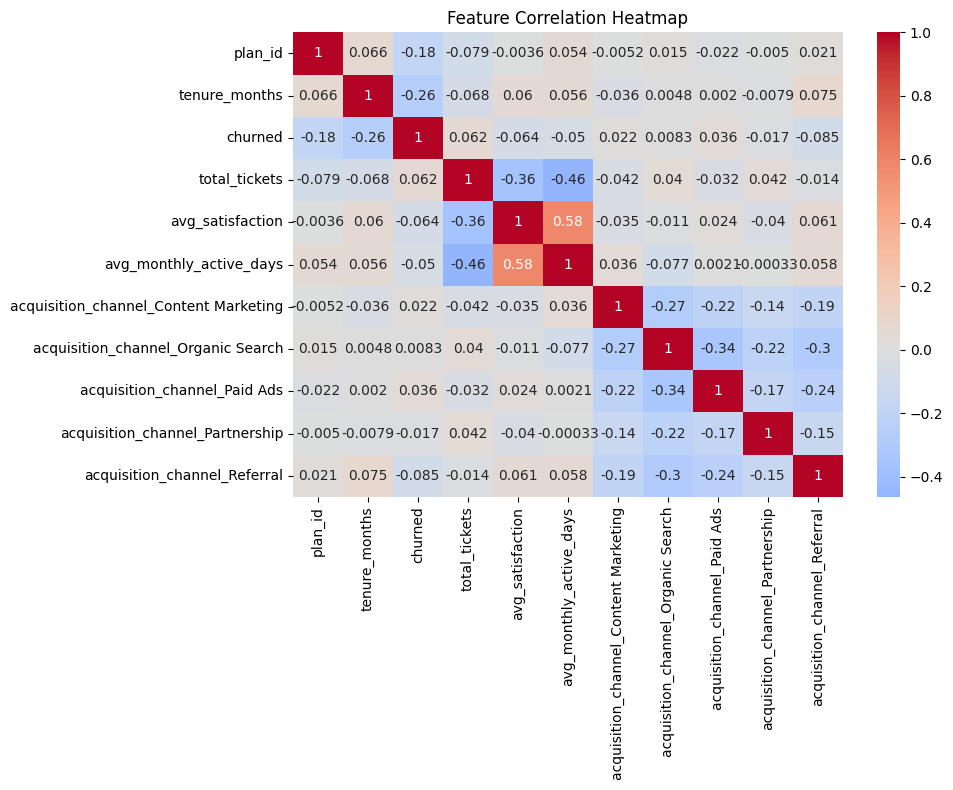

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['customer_id']).corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

**Observation:** the tenure boxplot shows a real, visible gap — churned
customers have a clearly lower median tenure than active customers. The
satisfaction boxplot shows almost no visible difference between groups —
consistent with the near-zero linear correlation to churn found above.

This is a genuinely useful finding on its own: **a straight-line correlation
coefficient can miss a real effect if that effect isn't smooth across the whole
range.** Project 1's SQL analysis bucketed customers by ticket count and found a
real, strong pattern (31% churn at 0 tickets, climbing to 48% at 8+ tickets) —
concentrated at the extreme, not a steady trend. That's exactly the kind of
pattern a correlation matrix is blind to.

## Finding → So What → Recommendation

**Finding:** Tenure and plan tier are the strongest predictors of churn — newer,
lower-tier customers are consistently more likely to churn. Support ticket volume
and satisfaction show very weak *linear* correlation with churn (0.06 and -0.06),
but Project 1's bucketed SQL analysis found a real, strong pattern concentrated at
the extreme (8+ tickets) — a reminder that correlation coefficients can miss
non-linear effects. The tuned model achieves 67.9% recall, correctly identifying
roughly 2 out of every 3 customers who will actually churn.

**So what:** A model that only catches 1 in 3 at-risk customers would leave most
preventable churn undetected. By deliberately trading some accuracy for recall
(prioritizing catching real churners over avoiding false alarms), PulseMetrics
gets a usable early-warning signal — because missing a real churner costs the
full customer relationship, while a false alarm only costs an unnecessary
retention outreach.

**Recommendation:** Score all currently active customers monthly with this model
and prioritize proactive retention outreach — the same 60-day onboarding
check-in from Project 1 — for anyone flagged as high-risk, focusing especially
on new customers on lower-tier plans with high support-ticket volume.